# Surrogate Model Stress Test (qubit_TransmonCross_cap_matrix)
## Gaussian Augmentation + Brute Force Search

We are going to generate thousands of augmented Qiskit Metal parameter sets by adding Gaussian noise based on qiskit metal params of test samples. Then well run them through the surrogate model to predict the capacitance, and save the best
ones to simulate in Ansys HFSS.

## Configuration

In [1]:
from parameters_surrogate import *

## Library

In [2]:
import os, gc, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

## Load Dataset & Surrogate Model

In [3]:
def load_scaled_split(kind, split):
    return np.load(f'{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy', allow_pickle=True)

X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Qiskit params):  {X_train.shape[1]} columns: {qiskit_param_names}')
print(f'Outputs (Capacitance):   {y_train.shape[1]} columns: {cap_column_names}')
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Inputs (Qiskit params):  3 columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
Outputs (Capacitance):   6 columns: ['cross_to_ground', 'claw_to_ground', 'cross_to_claw', 'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
Training samples: 1353, Test samples: 291


In [4]:
tf.keras.backend.clear_session()
gc.collect()

chosen_path = 'model/best_keras_model_model2_surrogate.keras'
with tf.device('/CPU:0'):
    surrogate = load_model(chosen_path, compile=False)

print(f'Loaded surrogate: {chosen_path}')
surrogate.summary()

I0000 00:00:1772755261.735081    2141 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18292 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:05:00.0, compute capability: 8.0


Loaded surrogate: model/best_keras_model_model2_surrogate.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 352)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         2,118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,526 (13.77 KB)

 Trainable params: 3,526 (13.77 KB)

 Non-trainable params: 0 (0.00 B)

## Load Scalers for Unscaling

In [5]:
# Load all scalers so we can go back and forth between scaled and unscaled
qiskit_scalers = {}
for name in qiskit_param_names:
    qiskit_scalers[name] = joblib.load(f'scalers/scaler_y_linear_{name}.save')

cap_scalers = {}
for name in cap_column_names:
    cap_scalers[name] = joblib.load(f'scalers/scaler_X_linear_{name}.save')

def unscale_qiskit(X_scaled):
    """Unscale Qiskit Metal params from [0,1] back to real values."""
    X_out = X_scaled.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].inverse_transform(X_out[:, j:j+1]).ravel()
    return X_out

def scale_qiskit(X_real):
    """Scale real Qiskit Metal params to [0,1]."""
    X_out = X_real.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].transform(X_out[:, j:j+1]).ravel()
    return X_out

def unscale_cap(y_scaled):
    """Unscale capacitance predictions back to real values."""
    y_out = y_scaled.copy()
    for j, name in enumerate(cap_column_names):
        y_out[:, j] = cap_scalers[name].inverse_transform(y_out[:, j:j+1]).ravel()
    return y_out

# Quick test
X_test_unscaled = unscale_qiskit(np.asarray(X_test))
print('Unscaled test set param ranges:')
for j, name in enumerate(qiskit_param_names):
    short = name.replace('design_options.', '')
    vals = X_test_unscaled[:, j]
    print(f'  {short:30s}  min={vals.min()}  max={vals.max()}  mean={vals.mean()}')

Unscaled test set param ranges:
  connection_pads.readout.claw_length  min=7e-05  max=0.00037  mean=0.00017103092783505154
  connection_pads.readout.ground_spacing  min=4.1e-06  max=1e-05  mean=7.091752577319587e-06
  cross_length                    min=9e-05  max=0.00042  mean=0.0002902405498281787


## Identify Integer vs Continuous Parameters

We need to know which parameters are integers (like finger_count) so we can
use different noise for those and Gaussian noise for the continuous ones.

In [6]:
#see if all of the training sets are integers for a specific column
X_all_unscaled = unscale_qiskit(np.vstack([X_train, X_val, X_test]).astype('float64'))

is_integer_param = []
integer_unique_vals = {}  
for j, name in enumerate(qiskit_param_names):
    vals = X_all_unscaled[:, j]
    all_integer = np.allclose(vals, np.round(vals))
    is_integer_param.append(all_integer)
    if all_integer:
        integer_unique_vals[j] = sorted(set(np.round(vals).astype(int)))
        print(f'  {name}: INTEGER — unique values: {integer_unique_vals[j]}')
    else:
        print(f'  {name}: CONTINUOUS — range [{vals.min()}, {vals.max()}]')

#figure out the range for each parameter
X_train_unscaled = unscale_qiskit(np.asarray(X_train).astype('float64'))
param_ranges = X_train_unscaled.max(axis=0) - X_train_unscaled.min(axis=0)
print(f'\nParameter ranges: {param_ranges}')

  design_options.connection_pads.readout.claw_length: CONTINUOUS — range [7e-05, 0.00039999999999999996]
  design_options.connection_pads.readout.ground_spacing: CONTINUOUS — range [4.1e-06, 1e-05]
  design_options.cross_length: CONTINUOUS — range [9e-05, 0.00042]

Parameter ranges: [3.3e-04 5.9e-06 3.3e-04]


## Make the gaussians and get the 'noisy' points

Pick some samples from the test set to center the gaussians on, then based on the gaussian associated with each one make 'noisy' copys.

Also here we try many sigma widths to see where the surrogate starts to fail

In [7]:
N_SEED_SAMPLES = 30          #how many real test samples to use as the gaussian centers
N_NOISY_PER_SEED = 200       #how many noisy copies per seed (total_points = N_SEED * N_NOISY)
SIGMA_FRACTIONS = [0.01, 0.02, 0.05, 0.10, 0.20]  # fraction of param range to use as sigma

np.random.seed(42) #set this to keep the 'random' selections the same on different trials

#get points from test set to center gaussian on 
seed_indices = np.random.choice(len(X_test), size=min(N_SEED_SAMPLES, len(X_test)), replace=False)
seed_samples_scaled = np.asarray(X_test)[seed_indices]
seed_samples_unscaled = unscale_qiskit(seed_samples_scaled.astype('float64'))
# getting their actual target capacitances to compare to 
#(the 'best' ones are picked from comparing to the caps associated with the mean test point)
seed_caps_scaled = np.asarray(y_test)[seed_indices]  

print(f'Selected {len(seed_indices)} seed samples from test set')
print(f'Will generate {N_NOISY_PER_SEED} noisy copies each at {len(SIGMA_FRACTIONS)} sigma levels')
print(f'Total augmented samples per sigma: {len(seed_indices) * N_NOISY_PER_SEED}')

Selected 30 seed samples from test set
Will generate 200 noisy copies each at 5 sigma levels
Total augmented samples per sigma: 6000


In [8]:
def generate_augmented(seed_unscaled, n_copies, sigma_fraction, param_ranges,
                       is_integer, integer_vals):
    #make noisy copies of a single sample. make sure everything is unscaled
    #everything is continuous so just add Gaussian noise with sigma=sigma_fraction*param_range
    
    n_params = len(seed_unscaled)
    copies = np.tile(seed_unscaled, (n_copies, 1)) 
    
    for j in range(n_params):
        sigma = sigma_fraction * param_ranges[j]
        noise = np.random.normal(0, sigma, size=n_copies)
        copies[:, j] += noise
    
    return copies

## Run each of the samples through the surrogate and time everything

In [10]:
all_results = {}
#go through each sigma
for sigma_frac in SIGMA_FRACTIONS:
    print(f'\n{"-"*70}')
    print(f'Sigma fraction: {sigma_frac} ({sigma_frac*100:.0f}% of param range)')
    print(f'{"-"*70}')

    #store the samples, index number associated with test point for that gaus, 
    #and capacitance associated with the test point
    all_augmented_unscaled = []  
    all_seed_idx = []            
    all_target_caps_scaled = []  
    
    for i, si in enumerate(seed_indices):
        aug_unscaled = generate_augmented(
            seed_samples_unscaled[i], N_NOISY_PER_SEED, sigma_frac,
            param_ranges, is_integer_param, integer_unique_vals)
        all_augmented_unscaled.append(aug_unscaled)
        all_seed_idx.extend([si] * N_NOISY_PER_SEED)
        all_target_caps_scaled.extend([seed_caps_scaled[i]] * N_NOISY_PER_SEED)
    
    all_augmented_unscaled = np.vstack(all_augmented_unscaled)
    all_seed_idx = np.array(all_seed_idx)
    all_target_caps_scaled = np.array(all_target_caps_scaled)
    
    # scale the 'noisy' params back to [0,1] for the surrogate
    all_augmented_scaled = scale_qiskit(all_augmented_unscaled)
    
    #actually run through surrogate and time it
    print(f'Running {len(all_augmented_scaled)} samples through surrogate...')
    t0 = time.time()
    with tf.device('/CPU:0'):
        predicted_caps_scaled = surrogate.predict(all_augmented_scaled.astype('float32'), verbose=0)
    t1 = time.time()
    total_time = t1 - t0
    per_sample_us = (total_time / len(all_augmented_scaled)) * 1e6
    print(f'  Time: {total_time:.3f}s total, {per_sample_us:.1f} μs/sample')
    
    # firnd how close is surrogate prediction to the target capacitance, make an error based on that
    # (MSE per sample between predicted cap and target cap)
    cap_errors = np.mean((predicted_caps_scaled - all_target_caps_scaled) ** 2, axis=1)
    
    # unscale 
    predicted_caps_unscaled = unscale_cap(predicted_caps_scaled)
    target_caps_unscaled = unscale_cap(all_target_caps_scaled)
    
    # Percentage error per capacitance column
    eps = 1e-15
    pct_errors = 100.0 * np.abs(predicted_caps_unscaled - target_caps_unscaled) / (np.abs(target_caps_unscaled) + eps)
    mean_pct_error_per_sample = pct_errors.mean(axis=1)
    
    all_results[sigma_frac] = {
        'augmented_unscaled': all_augmented_unscaled,
        'augmented_scaled': all_augmented_scaled,
        'seed_idx': all_seed_idx,
        'predicted_caps_scaled': predicted_caps_scaled,
        'predicted_caps_unscaled': predicted_caps_unscaled,
        'target_caps_unscaled': target_caps_unscaled,
        'cap_errors_mse': cap_errors,
        'pct_errors': pct_errors,
        'mean_pct_per_sample': mean_pct_error_per_sample,
        'total_time': total_time,
        'per_sample_us': per_sample_us,
    }
    
    print(f'  Mean % error: {mean_pct_error_per_sample.mean():.6f}%')
    print(f'  Median % error: {np.median(mean_pct_error_per_sample):.6f}%')
    print(f'  90th percentile: {np.percentile(mean_pct_error_per_sample, 90):.2f}%')
    print(f'  Max % error: {mean_pct_error_per_sample.max():.2f}%')


----------------------------------------------------------------------
Sigma fraction: 0.01 (1% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 5.807s total, 967.9 μs/sample
  Mean % error: 1.290498%
  Median % error: 1.121087%
  90th percentile: 2.40%
  Max % error: 7.42%

----------------------------------------------------------------------
Sigma fraction: 0.02 (2% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 5.172s total, 862.0 μs/sample
  Mean % error: 2.474070%
  Median % error: 2.139698%
  90th percentile: 4.57%
  Max % error: 14.34%

----------------------------------------------------------------------
Sigma fraction: 0.05 (5% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


...

  Time: 6.498s total, 1083.0 μs/sample
  Mean % error: 6.315144%
  Median % error: 5.406401%
  90th percentile: 11.82%
  Max % error: 42.24%

----------------------------------------------------------------------
Sigma fraction: 0.1 (10% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 6.511s total, 1085.1 μs/sample
  Mean % error: 12.294821%
  Median % error: 10.563386%
  90th percentile: 22.85%
  Max % error: 69.82%

----------------------------------------------------------------------
Sigma fraction: 0.2 (20% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 6.999s total, 1166.5 μs/sample
  Mean % error: 25.964653%
  Median % error: 22.018246%
  90th percentile: 48.02%
  Max % error: 235.28%


## Visualize the results

First see how 'accuracy' scales with sigma, although this isnt really accurate because it compares values far away from the center points to the ones close, so we expect points from the higher sigma gaussian to do worse because they are further from the center point that we compare the capacitance values to

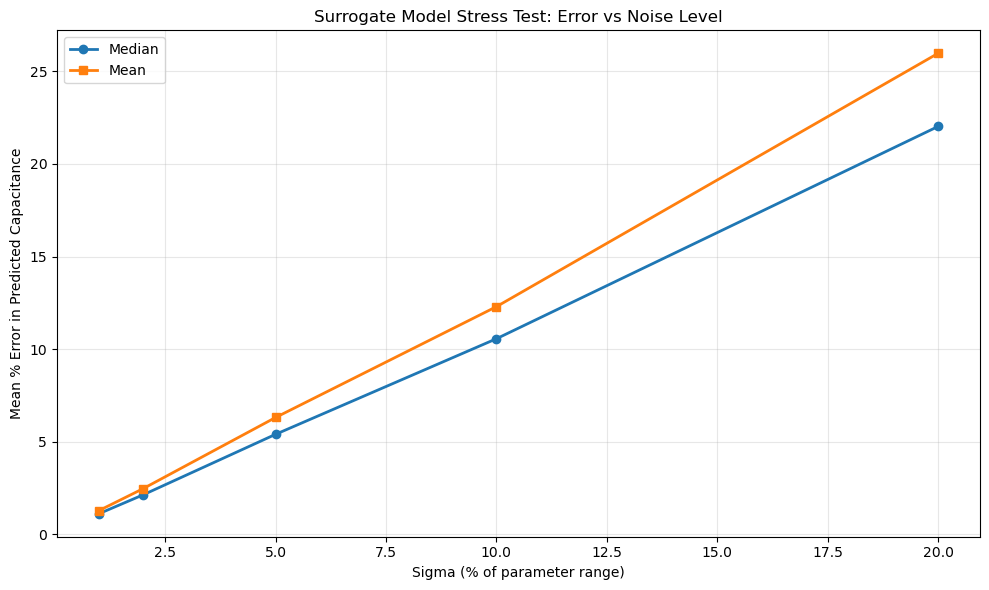

In [11]:
#plot error vs sigma to see where the surrogate starts to fail
sigmas = sorted(all_results.keys())
medians = [np.median(all_results[s]['mean_pct_per_sample']) for s in sigmas]
means = [all_results[s]['mean_pct_per_sample'].mean() for s in sigmas]
maxes = [all_results[s]['mean_pct_per_sample'].max() for s in sigmas]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([s*100 for s in sigmas], medians, 'o-', label='Median', linewidth=2)
ax.plot([s*100 for s in sigmas], means, 's-', label='Mean', linewidth=2)
ax.set_xlabel('Sigma (% of parameter range)')
ax.set_ylabel('Mean % Error in Predicted Capacitance')
ax.set_title('Surrogate Model Stress Test: Error vs Noise Level')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/surrogate_stress_test_error_vs_sigma.pdf')
plt.show()

In [12]:
# timing summary
print(f'{"Sigma %":>10s} {"Total Time":>12s} {"μs/sample":>12s} {"Samples":>10s}')
print('-' * 50)
for s in sigmas:
    r = all_results[s]
    n = len(r['augmented_scaled'])
    print(f'{s*100:10.0f} {r["total_time"]:12.3f}s {r["per_sample_us"]:12.1f} {n:10d}')
print()
print('For comparison, a single Ansys HFSS simulation takes ~10 minutes.')

   Sigma %   Total Time    μs/sample    Samples
--------------------------------------------------
         1        5.807s        967.9       6000
         2        5.172s        862.0       6000
         5        6.498s       1083.0       6000
        10        6.511s       1085.1       6000
        20        6.999s       1166.5       6000

For comparison, a single Ansys HFSS simulation takes ~10 minutes.


## Pick Best Candidates for Ansys Validation

In [13]:
# For each sigma level, find the best candidates (lowest error between
# surrogate-predicted cap and the target cap we want to achieve)

N_BEST = 10  # how many best candidates to pick per sigma

best_candidates = {}
for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    # Sort by MSE error 
    sorted_idx = np.argsort(r['cap_errors_mse'])
    best_idx = sorted_idx[:N_BEST]
    
    best_candidates[sigma_frac] = {
        'indices': best_idx,
        'params_unscaled': r['augmented_unscaled'][best_idx],
        'params_scaled': r['augmented_scaled'][best_idx],
        'predicted_caps_unscaled': r['predicted_caps_unscaled'][best_idx],
        'target_caps_unscaled': r['target_caps_unscaled'][best_idx],
        'mean_pct_error': r['mean_pct_per_sample'][best_idx],
        'seed_idx': r['seed_idx'][best_idx],
    }

print(f'Selected top {N_BEST} candidates per sigma level')

Selected top 10 candidates per sigma level


In [14]:
# Print the best candidates for each sigma level
for sigma_frac in SIGMA_FRACTIONS:
    bc = best_candidates[sigma_frac]
    print(f'\n{"-"*80}')
    print(f'BEST {N_BEST} CANDIDATES — Sigma = {sigma_frac*100:.0f}% of param range')
    print(f'{"-"*80}')
    
    for rank in range(len(bc['indices'])):
        print(f'\n--- Rank {rank+1} (mean cap error: {bc["mean_pct_error"][rank]:.2f}%) ---')
        print(f'  Seed test sample index: {bc["seed_idx"][rank]}')
        
        print(f'  Qiskit Metal params (for Ansys simulation):')
        for j, name in enumerate(qiskit_param_names):
            short = name.replace('design_options.', '')
            val = bc['params_unscaled'][rank, j]
            if is_integer_param[j]:
                print(f'    {short:30s}  {int(round(val))}')
            else:
                print(f'    {short:30s}  {val}')
        
        print(f'  Surrogate predicted capacitance:')
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {bc["predicted_caps_unscaled"][rank, j]:.6e}')
        
        print(f'  Target capacitance (what we want):')
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {bc["target_caps_unscaled"][rank, j]:.6e}')


--------------------------------------------------------------------------------
BEST 10 CANDIDATES — Sigma = 1% of param range
--------------------------------------------------------------------------------

--- Rank 1 (mean cap error: 0.06%) ---
  Seed test sample index: 90
  Qiskit Metal params (for Ansys simulation):
    connection_pads.readout.claw_length  0.0001307517394252159
    connection_pads.readout.ground_spacing  1.0078671426911707e-05
    cross_length                    0.0003213086979720285
  Surrogate predicted capacitance:
    cross_to_ground                 1.648661e+02
    claw_to_ground                  8.054996e+01
    cross_to_claw                   2.970001e+00
    cross_to_cross                  1.648821e+02
    claw_to_claw                    8.384071e+01
    ground_to_ground                3.085442e+02
  Target capacitance (what we want):
    cross_to_ground                 1.649500e+02
    claw_to_ground                  8.047731e+01
    cross_to_claw      

## Exporting Best Candidates for Firas to Simulate

In [15]:
# Save a CSV with all the best candidates that Fraz should simulate in Ansys
# Columns: sigma, rank, each Qiskit Metal param, each surrogate-predicted cap, each target cap

export_rows = []
for sigma_frac in SIGMA_FRACTIONS:
    bc = best_candidates[sigma_frac]
    for rank in range(len(bc['indices'])):
        row = {
            'sigma_for_gauss': sigma_frac * 100,
            'ranking_for_lowest_error': rank + 1,
            'test_set_index_as_gauss_mean': bc['seed_idx'][rank],
            'avg_percent_err_in_cap': bc['mean_pct_error'][rank],
        }
        #qiskit metal params
        for j, name in enumerate(qiskit_param_names):
            #short = name.replace('design_options.', '')
            val = bc['params_unscaled'][rank, j]
            row[f'{name}'] = int(round(val)) if is_integer_param[j] else val
        #surrogate predicted caps
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'surrogate_pred_{short}'] = bc['predicted_caps_unscaled'][rank, j]
        #target caps
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'target_{short}'] = bc['target_caps_unscaled'][rank, j]
        export_rows.append(row)

df_export = pd.DataFrame(export_rows)
csv_path = 'best_candidates_for_ansys_validation_50.csv'
df_export.to_csv(csv_path, index=False, float_format='%.6g')
display(df_export)

,sigma_for_gauss,ranking_for_lowest_error,test_set_index_as_gauss_mean,avg_percent_err_in_cap,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_cross_to_ground,surrogate_pred_claw_to_ground,surrogate_pred_cross_to_claw,surrogate_pred_cross_to_cross,surrogate_pred_claw_to_claw,surrogate_pred_ground_to_ground,target_cross_to_ground,target_claw_to_ground,target_cross_to_claw,target_cross_to_cross,target_claw_to_claw,target_ground_to_ground
0,1.0,1,90,0.057621,0.000131,0.000010,0.000321,164.866150,80.549957,2.970001,164.882126,83.840714,308.544220,164.94995,80.47731,2.96898,164.94995,83.75842,308.63960
1,1.0,2,60,0.054629,0.000270,0.000010,0.000370,188.729355,129.315231,6.544793,188.707733,136.361832,385.295227,188.81674,129.25054,6.53716,188.81674,136.30873,385.36458
2,1.0,3,237,0.078017,0.000150,0.000010,0.000260,131.203430,87.363266,3.570215,131.180557,91.332489,275.833069,131.20105,87.29319,3.57700,131.20105,91.24738,276.07444
3,1.0,4,5,0.105618,0.000100,0.000005,0.000250,130.757004,69.031555,3.170901,130.727234,72.554222,256.287323,130.73017,69.00516,3.18581,130.73017,72.53547,256.08539
4,1.0,5,5,0.095785,0.000100,0.000005,0.000249,130.580307,69.050964,3.179940,130.550674,72.583664,256.099945,130.73017,69.00516,3.18581,130.73017,72.53547,256.08539
5,1.0,6,60,0.048019,0.000270,0.000010,0.000370,188.998947,129.239044,6.535403,188.978546,136.275146,385.539978,188.81674,129.25054,6.53716,188.81674,136.30873,385.36458
6,1.0,7,125,0.186415,0.000079,0.000010,0.000169,83.725128,62.622143,1.991687,83.793594,65.009453,195.085449,83.81420,62.65788,1.97709,83.81420,65.00539,195.44907
7,1.0,8,202,0.104627,0.000140,0.000010,0.000240,120.268875,83.876511,3.355937,120.261398,87.650375,259.489655,120.39565,83.77095,3.35849,120.39565,87.53048,259.30308
8,1.0,9,60,0.060584,0.000271,0.000010,0.000371,188.917480,129.380981,6.536049,188.897598,136.418625,385.629669,188.81674,129.25054,6.53716,188.81674,136.30873,385.36458
9,1.0,10,202,0.139310,0.000139,0.000010,0.000240,120.470963,83.670494,3.344721,120.463135,87.432030,259.497223,120.39565,83.77095,3.35849,120.39565,87.53048,259.30308


In [17]:
export_rows = []
for sigma_frac in SIGMA_FRACTIONS:
    bc = best_candidates[sigma_frac]
    for rank in range(2):  # best 2
        row = {
            'sigma_for_gauss': sigma_frac * 100,
            'ranking_for_lowest_error': rank + 1,
            'test_set_index_as_gauss_mean': bc['seed_idx'][rank],
            'avg_percent_err_in_cap': bc['mean_pct_error'][rank],
        }
        row['surrogate_inference_us'] = all_results[sigma_frac]['per_sample_us']
        for j, name in enumerate(qiskit_param_names):
            val = bc['params_unscaled'][rank, j]
            row[f'{name}'] = int(round(val)) if is_integer_param[j] else val
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'surrogate_pred_{short}'] = bc['predicted_caps_unscaled'][rank, j]
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'target_{short}'] = bc['target_caps_unscaled'][rank, j]
        
        export_rows.append(row)
df_export = pd.DataFrame(export_rows)
csv_path = 'best_candidates_for_ansys_validation_10.csv'
df_export.to_csv(csv_path, index=False)
display(df_export)

,sigma_for_gauss,ranking_for_lowest_error,test_set_index_as_gauss_mean,avg_percent_err_in_cap,surrogate_inference_us,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_cross_to_ground,surrogate_pred_claw_to_ground,surrogate_pred_cross_to_claw,surrogate_pred_cross_to_cross,surrogate_pred_claw_to_claw,surrogate_pred_ground_to_ground,target_cross_to_ground,target_claw_to_ground,target_cross_to_claw,target_cross_to_cross,target_claw_to_claw,target_ground_to_ground
0,1.0,1,90,0.057621,967.899998,0.000131,0.000010,0.000321,164.866150,80.549957,2.970001,164.882126,83.840714,308.544220,164.94995,80.47731,2.96898,164.94995,83.75842,308.63960
1,1.0,2,60,0.054629,967.899998,0.000270,0.000010,0.000370,188.729355,129.315231,6.544793,188.707733,136.361832,385.295227,188.81674,129.25054,6.53716,188.81674,136.30873,385.36458
2,2.0,1,45,0.080751,861.985445,0.000149,0.000009,0.000200,101.669441,89.319145,4.104399,101.674072,93.881317,242.696472,101.58489,89.39401,4.10747,101.58489,94.01724,242.67125
3,2.0,2,202,0.129164,861.985445,0.000141,0.000010,0.000240,120.265305,83.762878,3.341850,120.248039,87.526764,259.393219,120.39565,83.77095,3.35849,120.39565,87.53048,259.30308
4,5.0,1,45,0.153570,1083.010713,0.000149,0.000009,0.000200,101.780373,89.340515,4.120068,101.782150,93.917229,242.821411,101.58489,89.39401,4.10747,101.58489,94.01724,242.67125
5,5.0,2,262,0.456293,1083.010713,0.000070,0.000009,0.000240,126.472023,61.223610,1.798678,126.560837,63.206013,243.506805,126.78247,61.40273,1.82726,126.78247,63.49120,243.53847
6,10.0,1,90,0.460195,1085.091750,0.000130,0.000010,0.000319,164.653183,80.899132,3.005901,164.621414,84.234253,308.496765,164.94995,80.47731,2.96898,164.94995,83.75842,308.63960
7,10.0,2,230,0.319739,1085.091750,0.000230,0.000009,0.000279,144.577148,118.075752,6.375395,144.534866,124.982697,321.771240,144.68825,118.48249,6.31466,144.68825,125.33888,322.24286
8,20.0,1,262,0.366579,1166.475932,0.000071,0.000009,0.000241,127.049431,61.197285,1.840982,127.115707,63.240582,244.137039,126.78247,61.40273,1.82726,126.78247,63.49120,243.53847
9,20.0,2,101,0.275954,1166.475932,0.000238,0.000010,0.000409,219.074875,123.061058,5.900754,219.155838,129.312454,413.448059,219.69830,123.22641,5.86327,219.69830,129.52221,414.23350


## Per-Sigma Scatter Plots

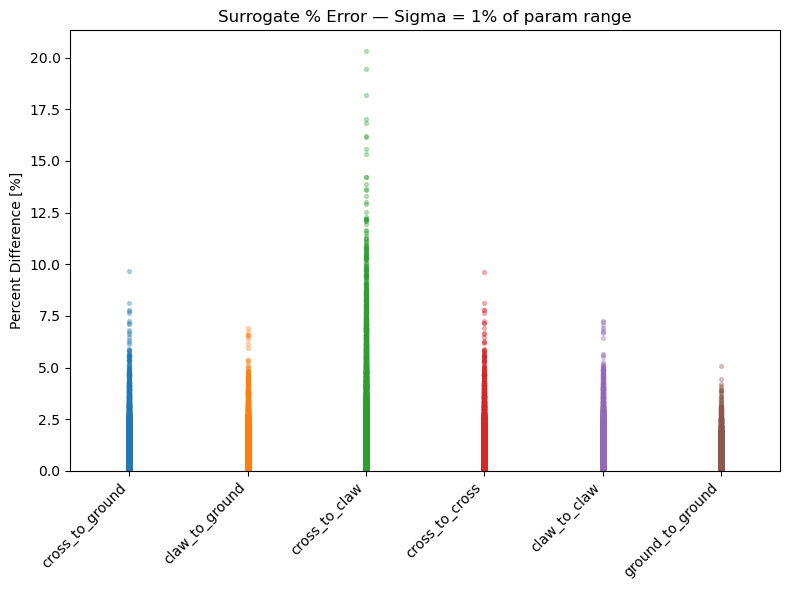

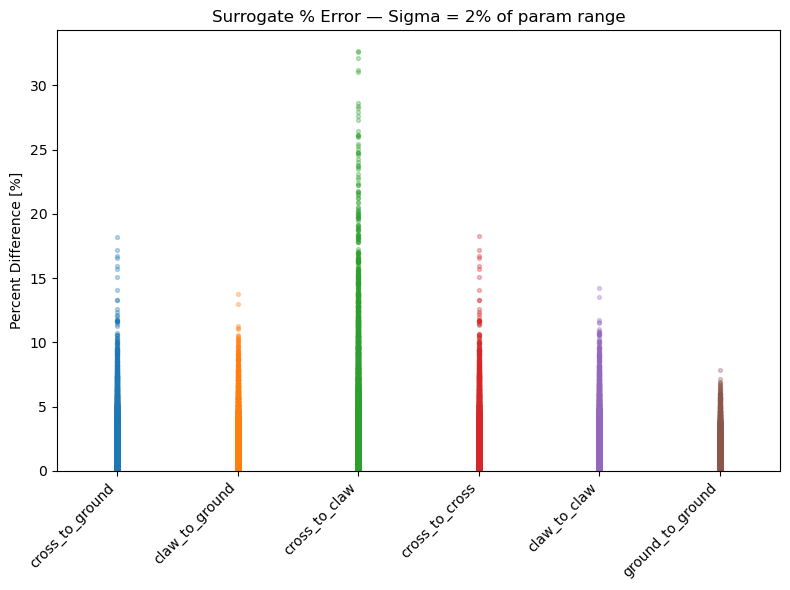

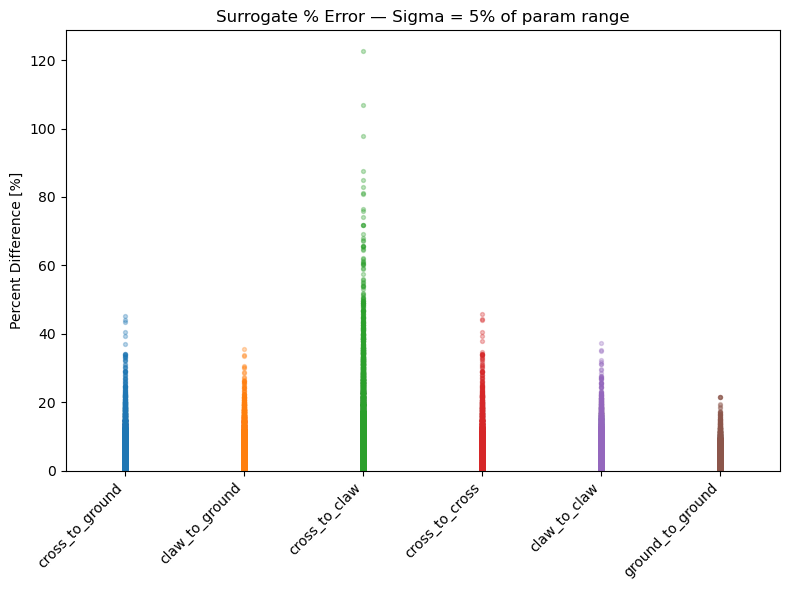

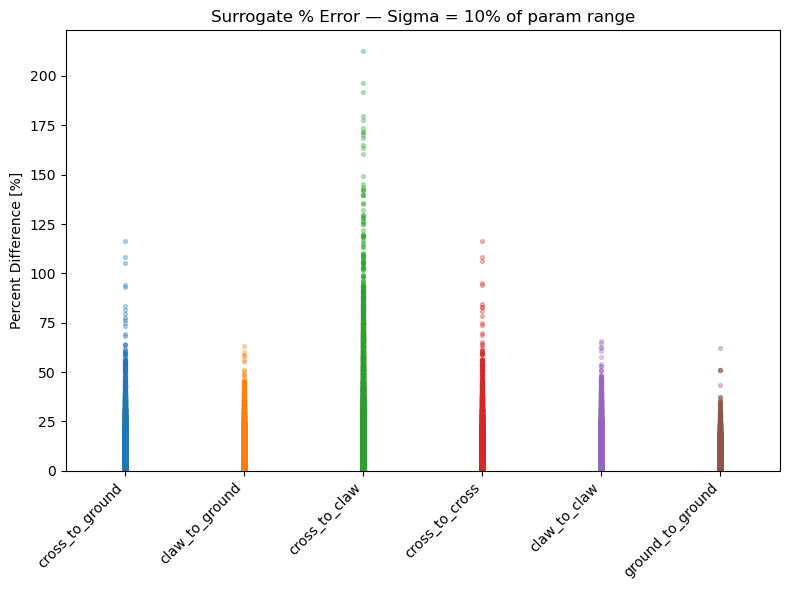

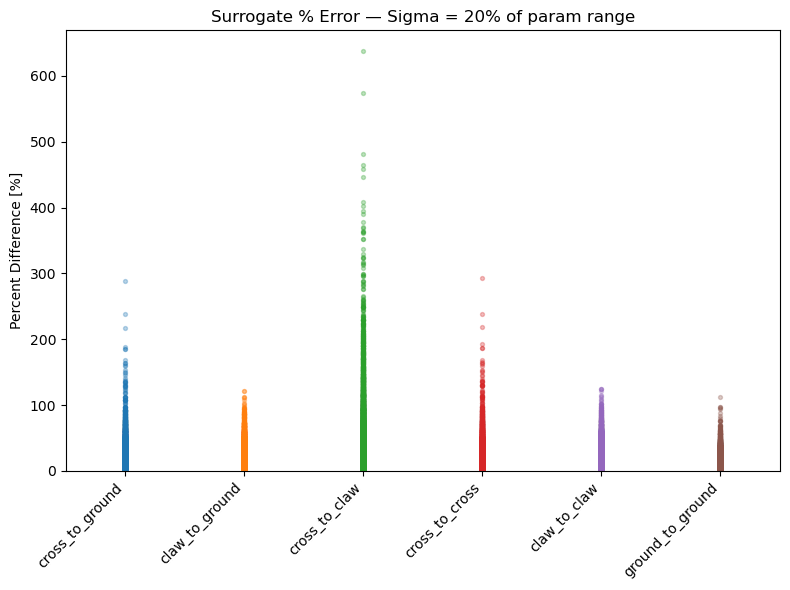

In [18]:
# for each sigma, scatter plot of % error per capacitance column
short_cap_names = [c.split('.')[-1] if '.' in c else c for c in cap_column_names]
n_caps = len(cap_column_names)

for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    fig, ax = plt.subplots(figsize=(8, 6))
    for j in range(n_caps):
        col_pct = r['pct_errors'][:, j]
        ax.scatter(np.full(len(col_pct), j), col_pct, s=8, alpha=0.3)
    ax.set_xticks(range(n_caps))
    ax.set_xticklabels(short_cap_names, rotation=45, ha='right')
    ax.set_ylabel('Percent Difference [%]')
    ax.set_title(f'Surrogate % Error — Sigma = {sigma_frac*100:.0f}% of param range')
    ax.set_ylim(0, None)
    ax.margins(y=0)
    ax.set_xlim(-0.5, n_caps - 0.5)
    plt.tight_layout()
    plt.savefig(f'plots/surrogate_stress_sigma_{int(sigma_frac*100)}_pct_scatter.pdf')
    plt.show()

## plot in 3d the gaussians to get a feeling for their shapes/ranges

Top 4 seeds by frequency in best candidates:
  Seed test idx 262: 6 best candidates
  Seed test idx 90: 5 best candidates
  Seed test idx 60: 5 best candidates
  Seed test idx 5: 4 best candidates


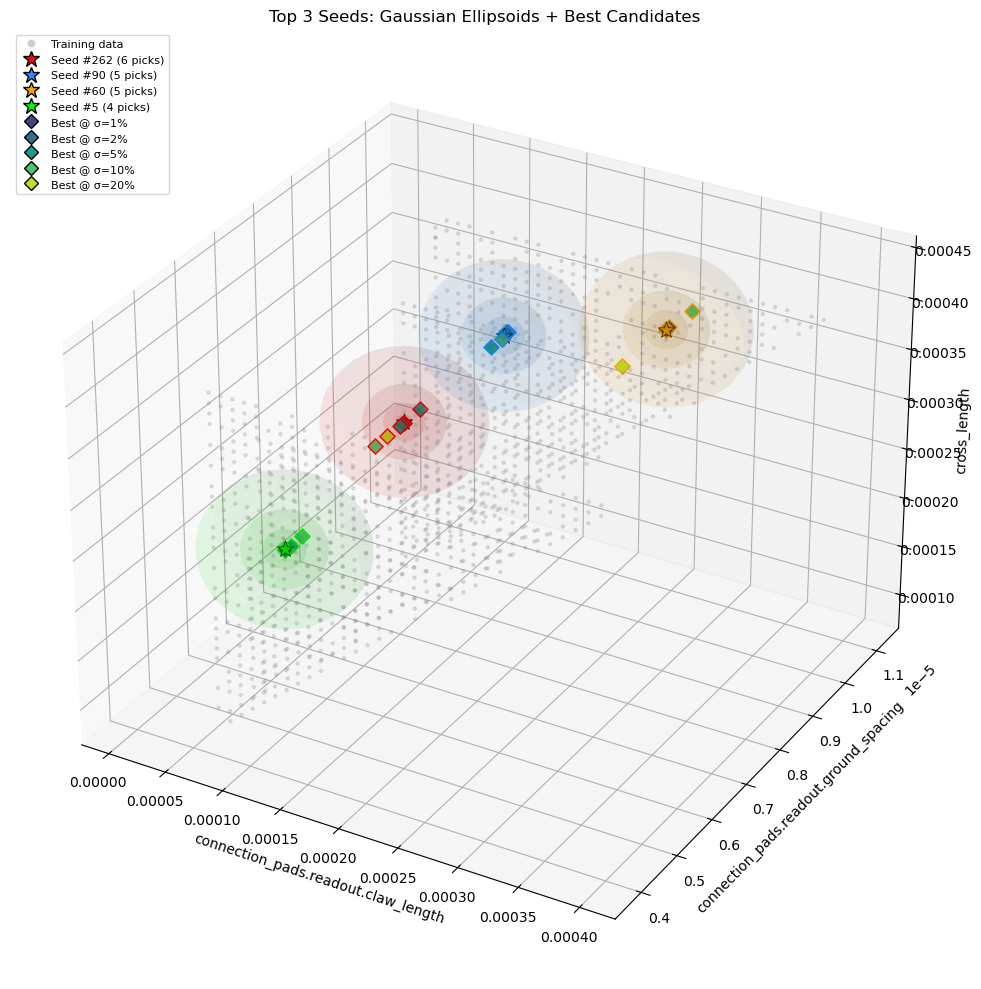

In [34]:
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter
from matplotlib.lines import Line2D

cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

def draw_ellipsoid(ax, center, sigmas, color, alpha=0.15):
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = center[0] + sigmas[0] * np.outer(np.cos(u), np.sin(v))
    y = center[1] + sigmas[1] * np.outer(np.sin(u), np.sin(v))
    z = center[2] + sigmas[2] * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0)

colors_sigma = plt.cm.viridis(np.linspace(0.2, 0.9, len(SIGMA_FRACTIONS)))
seed_idx_to_pos = {si: i for i, si in enumerate(seed_indices)}

# count how many of the best 10 per sigma came from each test value
seed_counts = Counter()
seed_to_best = {}
for sigma_frac in SIGMA_FRACTIONS:
    bc = best_candidates[sigma_frac]
    for rank in range(10):
        sid = bc['seed_idx'][rank]
        seed_counts[sid] += 1
        if sid not in seed_to_best:
            seed_to_best[sid] = []
        seed_to_best[sid].append({
            'sigma_frac': sigma_frac,
            'rank': rank,
            'params': bc['params_unscaled'][rank],
        })

# pick top 4 test values to plot gauss around
top_4_seeds = [sid for sid, count in seed_counts.most_common(4)]
print(f'Top 4 test vals by frequency in best candidates:')
for sid in top_4_seeds:
    print(f'  Seed test idx {sid}: {seed_counts[sid]} best candidates')

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# training data 
ax.scatter(X_train_unscaled[:, p0], X_train_unscaled[:, p1], X_train_unscaled[:, p2],
           c='gray', s=5, alpha=0.2, label='Training data')

# For each of the top 4 seeds: star + ellipsoids + diamonds
seed_colors = ['red', 'dodgerblue', 'orange', 'lime']
seed_markers = ['*', '*', '*']

for seed_rank, top_seed in enumerate(top_4_seeds):
    pos = seed_idx_to_pos[top_seed]
    sc = seed_colors[seed_rank]

    # Seed sample (star)
    ax.scatter(seed_samples_unscaled[pos, p0],
               seed_samples_unscaled[pos, p1],
               seed_samples_unscaled[pos, p2],
               c=sc, s=150, marker='*', edgecolors='black', linewidths=0.5, zorder=5)

    # Ellipsoids at each sigma
    center = [seed_samples_unscaled[pos, p0],
              seed_samples_unscaled[pos, p1],
              seed_samples_unscaled[pos, p2]]
    for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
        sigmas_3d = [sigma_frac * param_ranges[p0],
                     sigma_frac * param_ranges[p1],
                     sigma_frac * param_ranges[p2]]
        draw_ellipsoid(ax, center, sigmas_3d, sc, alpha=0.05)

    # Best candidates from this seed, color-coded by sigma
    for entry in seed_to_best[top_seed]:
        si_frac = SIGMA_FRACTIONS.index(entry['sigma_frac'])
        params = entry['params']
        ax.scatter(params[p0], params[p1], params[p2],
                   c=[colors_sigma[si_frac]], s=60, marker='D',
                   edgecolors=sc, linewidths=1.0, zorder=10)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, alpha=0.4, label='Training data'),
]
for i, (sid, sc) in enumerate(zip(top_4_seeds, seed_colors)):
    legend_elements.append(
        Line2D([0], [0], marker='*', color='w', markerfacecolor=sc,
               markeredgecolor='black', markersize=12,
               label=f'Seed #{sid} ({seed_counts[sid]} picks)'))
for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
    legend_elements.append(
        Line2D([0], [0], marker='D', color='w', markerfacecolor=colors_sigma[si_frac],
               markeredgecolor='black', markersize=7,
               label=f'Best @ σ={sigma_frac*100:.0f}%'))

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Top 3 Seeds: Gaussian Ellipsoids + Best Candidates')
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plots/surrogate_stress_3d_top3_seeds.pdf')
plt.show()